# Presentation visuals — Scenario Compass RDM

Five figures for the Friday presentation (ema-workbench 3.x API):

1. **fig1** — CO₂ trajectory fan chart
2. **fig2a** — CCP pruning path (cross-validation)
3. **fig2b** — CCP-pruned CART decision tree
4. **fig3** — Decision space scatter with PRIM box overlay
5. **fig4** — Two roads mechanism (4-panel)
6. **fig5** — PRIM parallel coordinates

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score
from ema_workbench.analysis import prim, cart

mpl.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         12,
    'axes.titlesize':    13,
    'axes.labelsize':    12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'savefig.dpi':       200,
    'savefig.bbox':      'tight',
})

C_DESIRED = '#2ca02c'
C_CCS     = '#ff7f0e'
C_FAILURE = '#9ecae1'
C_PRIM    = '#d62728'

print('Imports OK')

Imports OK


In [2]:
data = pd.read_csv('../antoine_folder/data_for_scenariodiscovery_full.csv')
print(f'Loaded {data.shape}')

data['outcome_group'] = 'Failure (no NZ by 2070)'
data.loc[data['success_nz2070'] & ~data['low_ccs_reliance'], 'outcome_group'] = 'NZ by 2070, CCS-reliant'
data.loc[data['desired_success'], 'outcome_group'] = 'Desired (NZ + low CCS)'

GRP_ORDER  = ['Failure (no NZ by 2070)', 'NZ by 2070, CCS-reliant', 'Desired (NZ + low CCS)']
GRP_COLORS = {'Failure (no NZ by 2070)': C_FAILURE, 'NZ by 2070, CCS-reliant': C_CCS, 'Desired (NZ + low CCS)': C_DESIRED}

print(data['outcome_group'].value_counts()[GRP_ORDER].to_string())

Loaded (1599, 226)
outcome_group
Failure (no NZ by 2070)    1102
NZ by 2070, CCS-reliant     125
Desired (NZ + low CCS)      372


## Figure 1 — CO₂ trajectory fan chart

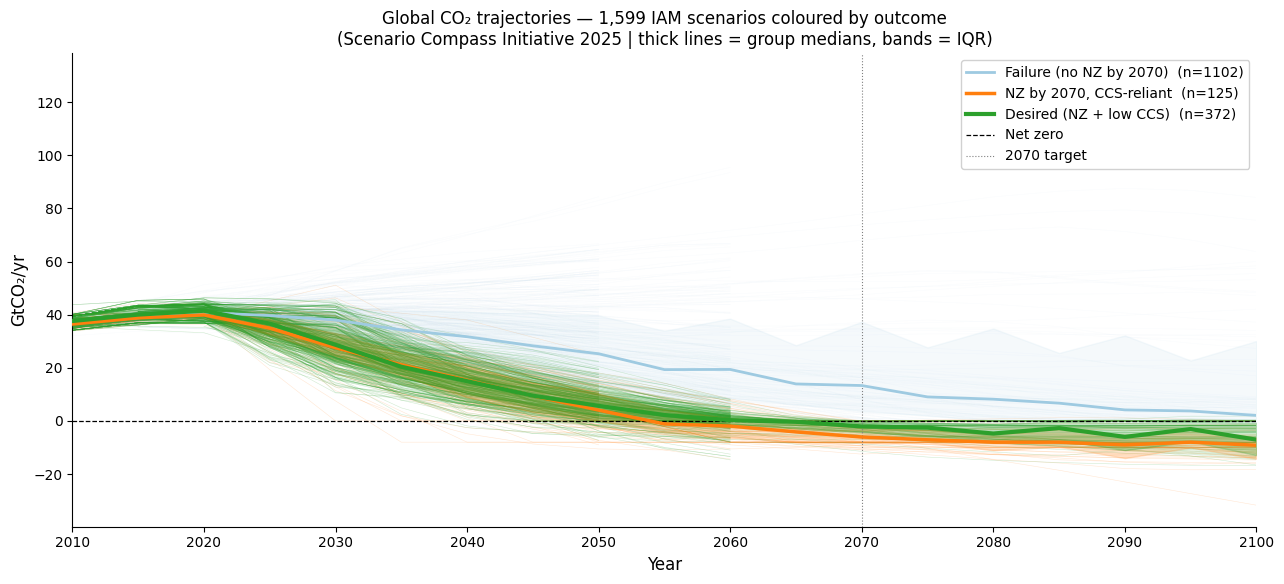

fig1 saved


In [3]:
co2_cols = sorted(
    [c for c in data.columns if c.startswith('Emissions|CO2|')],
    key=lambda c: int(c.split('|')[-1])
)
years_co2 = [int(c.split('|')[-1]) for c in co2_cols]

LINE_ALPHA  = {'Failure (no NZ by 2070)': 0.05, 'NZ by 2070, CCS-reliant': 0.18, 'Desired (NZ + low CCS)': 0.22}
BAND_ALPHA  = {'Failure (no NZ by 2070)': 0.10, 'NZ by 2070, CCS-reliant': 0.20, 'Desired (NZ + low CCS)': 0.25}
MEDIAN_LW   = {'Failure (no NZ by 2070)': 2.0,  'NZ by 2070, CCS-reliant': 2.5,  'Desired (NZ + low CCS)': 3.0}

fig, ax = plt.subplots(figsize=(13, 6))

for grp in GRP_ORDER:
    sub = data[data['outcome_group'] == grp][co2_cols]
    col = GRP_COLORS[grp]
    n   = len(sub)
    step = 3 if grp == 'Failure (no NZ by 2070)' else 1
    for _, row in sub.iloc[::step].iterrows():
        ax.plot(years_co2, row.values / 1e3, color=col, alpha=LINE_ALPHA[grp], linewidth=0.4, zorder=2)
    p25 = sub.quantile(0.25).values / 1e3
    p75 = sub.quantile(0.75).values / 1e3
    ax.fill_between(years_co2, p25, p75, color=col, alpha=BAND_ALPHA[grp], zorder=3)
    med = sub.median().values / 1e3
    ax.plot(years_co2, med, color=col, linewidth=MEDIAN_LW[grp],
            label=f'{grp}  (n={n})', zorder=5)

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', zorder=4, label='Net zero')
ax.axvline(2070, color='gray', linewidth=0.8, linestyle=':', zorder=4, label='2070 target')
ax.set_xlim(2010, 2100)
ax.set_xlabel('Year')
ax.set_ylabel('GtCO\u2082/yr')
ax.set_title(
    'Global CO\u2082 trajectories \u2014 1,599 IAM scenarios coloured by outcome\n'
    '(Scenario Compass Initiative 2025 | thick lines = group medians, bands = IQR)',
    fontsize=12)
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.savefig('fig1_co2_fan_chart.png')
plt.show()
print('fig1 saved')

## Figure 2 — CCP-pruned CART decision tree

In [4]:
OUTCOME = 'desired_success'
FACTORS = [
    'Emissions|CO2|2030',
    'Primary Energy|Fossil|2030',
    'Primary Energy|Fossil|2050',
    'Primary Energy|Non-Biomass Renewables|2030',
    'Primary Energy|Non-Biomass Renewables|2050',
    'Primary Energy|Biomass|2050',
    'Primary Energy|2050',
    'Final Energy|Electricity|2050',
]

sub = data[FACTORS + [OUTCOME]].dropna()
X   = sub[FACTORS].values
y   = sub[OUTCOME].astype(int).values
print(f'n={len(sub)}, positives={y.sum()} ({y.mean():.1%})')

n=1422, positives=322 (22.6%)


Best CV balanced_acc: 0.854 ± 0.020
Chosen alpha (1-std): 0.00653


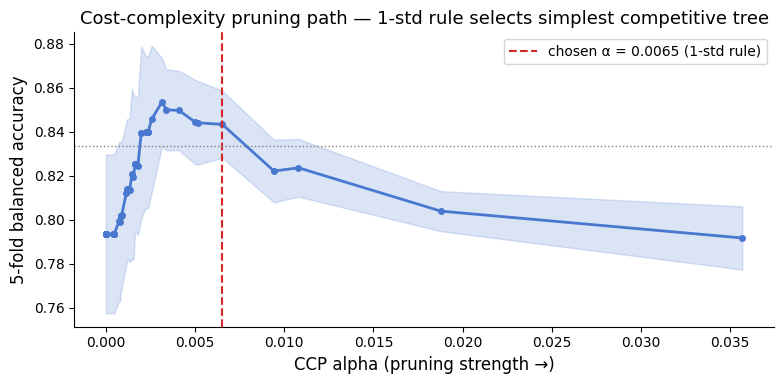

fig2a saved


In [5]:
# CCP path
clf_full = DecisionTreeClassifier(random_state=42, class_weight='balanced')
clf_full.fit(X, y)
path = clf_full.cost_complexity_pruning_path(X, y)
ccp_alphas = path.ccp_alphas[:-1]

# Sample 50 values log-uniformly to keep CV fast
if len(ccp_alphas) > 50:
    idx = np.unique(np.round(np.linspace(0, len(ccp_alphas)-1, 50)).astype(int))
    alphas_grid = ccp_alphas[idx]
else:
    alphas_grid = ccp_alphas

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_mean, cv_std = [], []
for alpha in alphas_grid:
    clf_cv = DecisionTreeClassifier(ccp_alpha=alpha, class_weight='balanced', random_state=42)
    scores = cross_val_score(clf_cv, X, y, cv=cv, scoring='balanced_accuracy')
    cv_mean.append(scores.mean())
    cv_std.append(scores.std())

cv_mean = np.array(cv_mean)
cv_std  = np.array(cv_std)

best_idx   = cv_mean.argmax()
threshold  = cv_mean[best_idx] - cv_std[best_idx]
chosen_idx = np.where(cv_mean >= threshold)[0][-1]   # simplest (largest alpha)
chosen_alpha = alphas_grid[chosen_idx]

print(f'Best CV balanced_acc: {cv_mean[best_idx]:.3f} \u00b1 {cv_std[best_idx]:.3f}')
print(f'Chosen alpha (1-std): {chosen_alpha:.5f}')

# Plot CCP path
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas_grid, cv_mean, 'o-', color='#4878d0', linewidth=2, markersize=4)
ax.fill_between(alphas_grid, cv_mean - cv_std, cv_mean + cv_std, alpha=0.2, color='#4878d0')
ax.axvline(chosen_alpha, color=C_PRIM, linestyle='--', linewidth=1.5,
           label=f'chosen \u03b1 = {chosen_alpha:.4f} (1-std rule)')
ax.axhline(threshold, color='gray', linestyle=':', linewidth=1.0)
ax.set_xlabel('CCP alpha (pruning strength \u2192)')
ax.set_ylabel('5-fold balanced accuracy')
ax.set_title('Cost-complexity pruning path \u2014 1-std rule selects simplest competitive tree')
ax.legend()
plt.tight_layout()
plt.savefig('fig2a_ccp_path.png')
plt.show()
print('fig2a saved')

Pruned tree: depth=4, leaves=8, train BAC=0.865

Feature importances:
Primary Energy|Fossil|2050       0.824806
Primary Energy|Biomass|2050      0.106827
Final Energy|Electricity|2050    0.068367


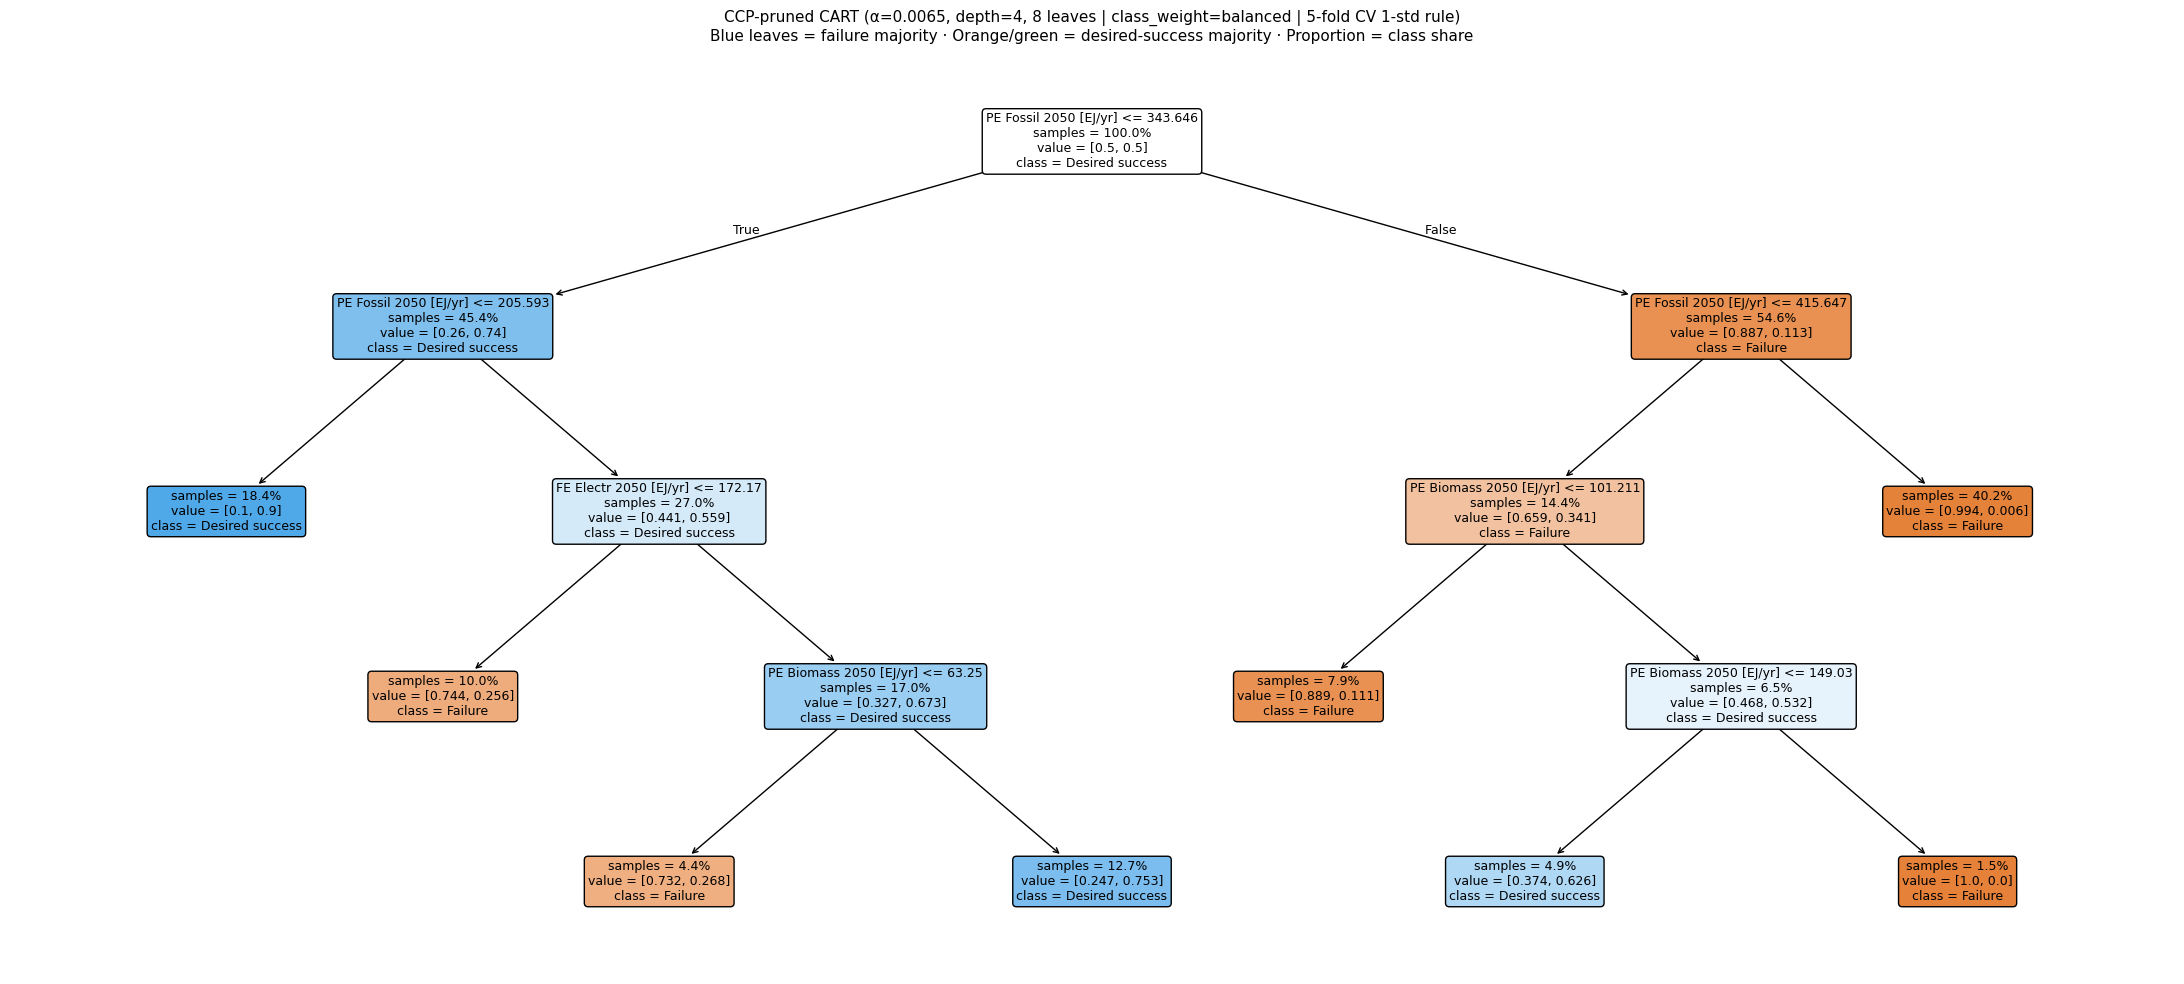

fig2b saved


In [6]:
# Build pruned tree (cap depth=4 for slide readability)
clf_pruned = DecisionTreeClassifier(
    ccp_alpha=chosen_alpha, max_depth=4,
    class_weight='balanced', random_state=42
)
clf_pruned.fit(X, y)
bac = balanced_accuracy_score(y, clf_pruned.predict(X))
print(f'Pruned tree: depth={clf_pruned.get_depth()}, leaves={clf_pruned.get_n_leaves()}, '
      f'train BAC={bac:.3f}')

imps = pd.Series(clf_pruned.feature_importances_, index=FACTORS).sort_values(ascending=False)
print('\nFeature importances:')
print(imps[imps > 0].to_string())

SHORT = {
    'Emissions|CO2|2030':                             'CO2 2030 [MtCO2/yr]',
    'Primary Energy|Fossil|2030':                     'PE Fossil 2030 [EJ/yr]',
    'Primary Energy|Fossil|2050':                     'PE Fossil 2050 [EJ/yr]',
    'Primary Energy|Non-Biomass Renewables|2030':     'PE Renew 2030 [EJ/yr]',
    'Primary Energy|Non-Biomass Renewables|2050':     'PE Renew 2050 [EJ/yr]',
    'Primary Energy|Biomass|2050':                    'PE Biomass 2050 [EJ/yr]',
    'Primary Energy|2050':                            'PE Total 2050 [EJ/yr]',
    'Final Energy|Electricity|2050':                  'FE Electr 2050 [EJ/yr]',
}
short_labels = [SHORT[f] for f in FACTORS]

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    clf_pruned,
    feature_names=short_labels,
    class_names=['Failure', 'Desired success'],
    filled=True, impurity=False, proportion=True,
    rounded=True, fontsize=9, ax=ax,
)
ax.set_title(
    f'CCP-pruned CART (\u03b1={chosen_alpha:.4f}, depth={clf_pruned.get_depth()}, '
    f'{clf_pruned.get_n_leaves()} leaves | class_weight=balanced | 5-fold CV 1-std rule)\n'
    'Blue leaves = failure majority \u00b7 Orange/green = desired-success majority \u00b7 Proportion = class share',
    fontsize=11
)
plt.tight_layout()
plt.savefig('fig2b_cart_pruned_tree.png')
plt.show()
print('fig2b saved')

## Figure 3 — Decision space scatter with PRIM box

In [7]:
# Run PRIM (ema-workbench v3 API: no 'threshold' kwarg)
sub_prim = data[FACTORS + [OUTCOME]].dropna()
x_prim   = sub_prim[FACTORS]
y_prim   = sub_prim[OUTCOME].astype(bool).values

prim_alg = prim.Prim(x_prim, y_prim, mass_min=0.05)
box1     = prim_alg.find_box()

traj   = box1.peeling_trajectory
cands  = traj[traj['coverage'] >= 0.9]
sel_id = int(cands.loc[cands['density'].idxmax(), 'id'])
box1.select(sel_id)

sel_row = traj[traj['id'] == sel_id].iloc[0]
print(f'PRIM box: id={sel_id}, coverage={sel_row["coverage"]:.3f}, '
      f'density={sel_row["density"]:.3f}, mass={sel_row["mass"]:.3f}, '
      f'res_dim={int(sel_row["res_dim"])}')

PRIM box: id=18, coverage=0.913, density=0.529, mass=0.391, res_dim=5


Primary Energy|Fossil|2050: [42.1, 407.5] EJ/yr
Emissions|CO2|2030:    [-0, 48899] MtCO₂/yr


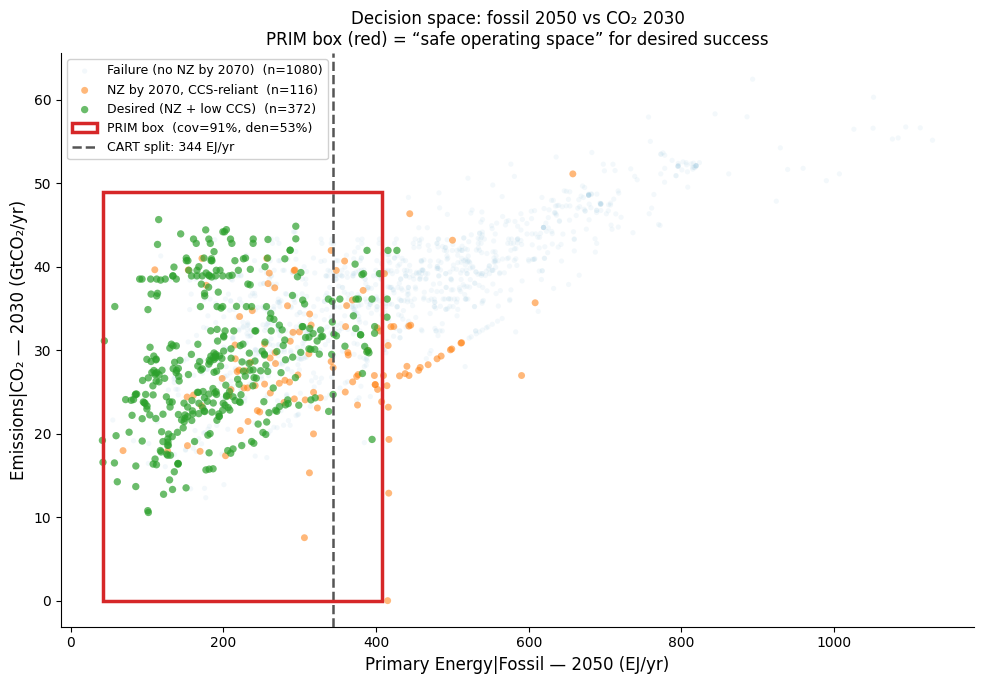

fig3 saved


In [8]:
FOSSIL_COL = 'Primary Energy|Fossil|2050'
CO2_COL    = 'Emissions|CO2|2030'

# box_lims[sel_id] rows: 0 = lower bound, 1 = upper bound
bl = box1.box_lims[sel_id]
fossil_lo, fossil_hi = bl.loc[0, FOSSIL_COL], bl.loc[1, FOSSIL_COL]
co2_lo,    co2_hi   = bl.loc[0, CO2_COL],    bl.loc[1, CO2_COL]
print(f'{FOSSIL_COL}: [{fossil_lo:.1f}, {fossil_hi:.1f}] EJ/yr')
print(f'{CO2_COL}:    [{co2_lo:.0f}, {co2_hi:.0f}] MtCO\u2082/yr')

# CART primary split on fossil
fossil_idx = FACTORS.index(FOSSIL_COL)
tree_ = clf_pruned.tree_
cart_splits = [tree_.threshold[i] for i in range(tree_.node_count) if tree_.feature[i] == fossil_idx]
primary_split = cart_splits[0] if cart_splits else None

plot_df = data[[FOSSIL_COL, CO2_COL, 'outcome_group']].dropna()

fig, ax = plt.subplots(figsize=(10, 7))

SCATTER_ALPHA = {'Failure (no NZ by 2070)': 0.12, 'NZ by 2070, CCS-reliant': 0.55, 'Desired (NZ + low CCS)': 0.70}
SCATTER_SIZE  = {'Failure (no NZ by 2070)': 14,   'NZ by 2070, CCS-reliant': 25,   'Desired (NZ + low CCS)': 28}
SCATTER_ZO    = {'Failure (no NZ by 2070)': 1,    'NZ by 2070, CCS-reliant': 3,    'Desired (NZ + low CCS)': 5}

for grp in GRP_ORDER:
    sub = plot_df[plot_df['outcome_group'] == grp]
    ax.scatter(sub[FOSSIL_COL], sub[CO2_COL] / 1e3,
               color=GRP_COLORS[grp], alpha=SCATTER_ALPHA[grp],
               s=SCATTER_SIZE[grp], label=f'{grp}  (n={len(sub)})',
               zorder=SCATTER_ZO[grp], edgecolors='none')

# PRIM box rectangle
w = fossil_hi - fossil_lo
h = (co2_hi - co2_lo) / 1e3
rect = mpatches.FancyBboxPatch(
    (fossil_lo, co2_lo / 1e3), w, h,
    boxstyle='square,pad=0', linewidth=2.5,
    edgecolor=C_PRIM, facecolor='none', zorder=8,
    label=f'PRIM box  (cov={sel_row["coverage"]:.0%}, den={sel_row["density"]:.0%})'
)
ax.add_patch(rect)

# CART primary split
if primary_split is not None:
    ax.axvline(primary_split, color='#555555', linewidth=1.8, linestyle='--',
               label=f'CART split: {primary_split:.0f} EJ/yr', zorder=7)

ax.set_xlabel('Primary Energy|Fossil \u2014 2050 (EJ/yr)')
ax.set_ylabel('Emissions|CO\u2082 \u2014 2030 (GtCO\u2082/yr)')
ax.set_title(
    'Decision space: fossil 2050 vs CO\u2082 2030\n'
    'PRIM box (red) = \u201csafe operating space\u201d for desired success',
    fontsize=12)
ax.legend(loc='upper left', framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.savefig('fig3_decision_space_scatter.png')
plt.show()
print('fig3 saved')

## Figure 4 — Two roads to success: mechanism (4-panel)

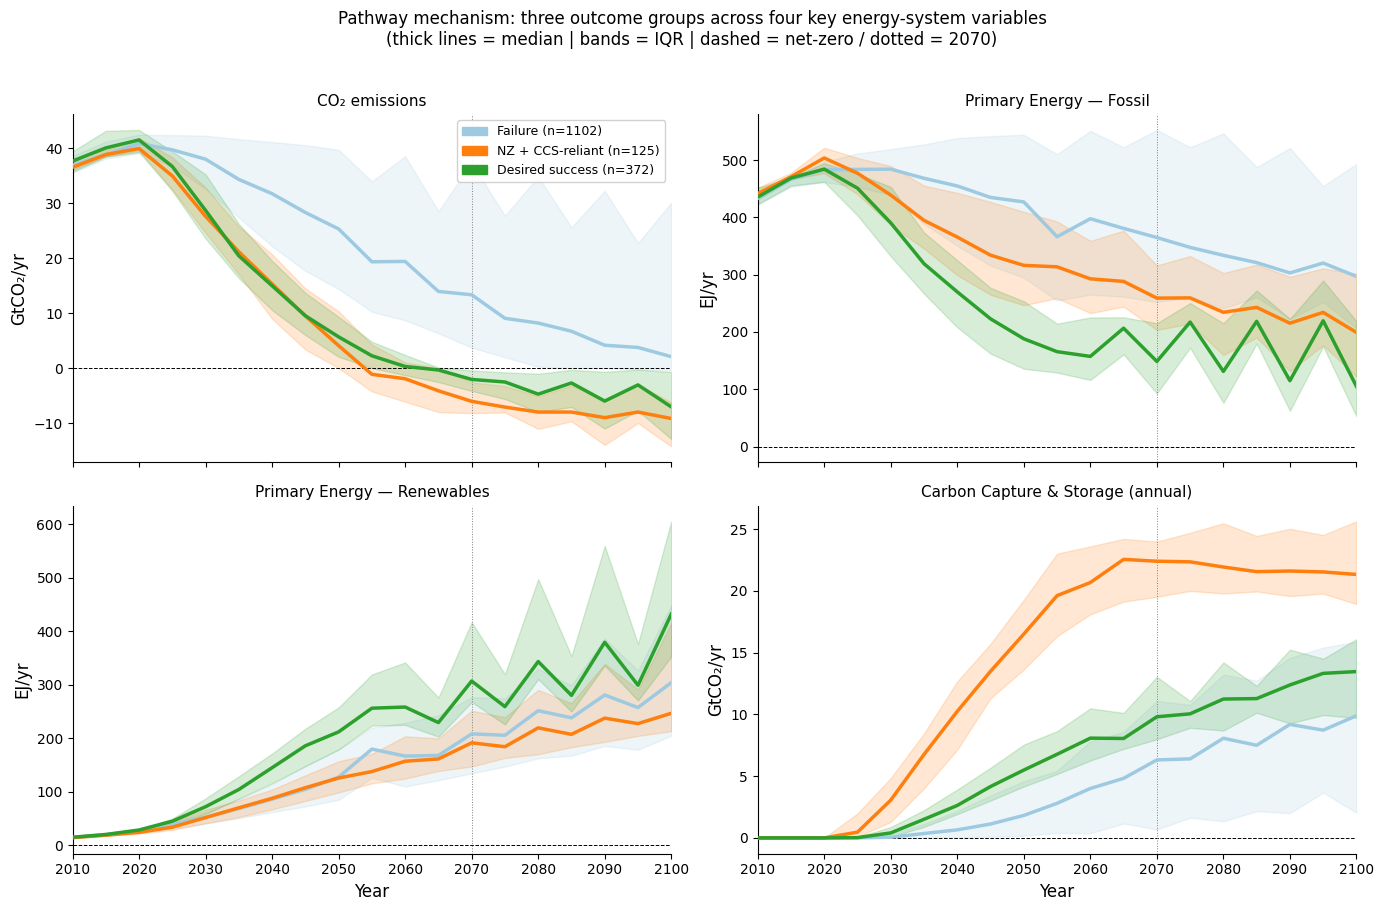

fig4 saved


In [9]:
def get_trajectories(df, var_prefix):
    cols = sorted(
        [c for c in df.columns if c.startswith(var_prefix + '|') and c.split('|')[-1].isdigit() and int(c.split('|')[-1]) % 5 == 0],
        key=lambda c: int(c.split('|')[-1])
    )
    yrs = [int(c.split('|')[-1]) for c in cols]
    out = {}
    for grp in GRP_ORDER:
        sub = df[df['outcome_group'] == grp][cols].dropna(how='all')
        out[grp] = (yrs, sub.median().values, sub.quantile(0.25).values, sub.quantile(0.75).values)
    return out

PANELS = [
    ('Emissions|CO2',                          'GtCO\u2082/yr',  1e3,  'CO\u2082 emissions'),
    ('Primary Energy|Fossil',                  'EJ/yr',          1.0,  'Primary Energy \u2014 Fossil'),
    ('Primary Energy|Non-Biomass Renewables',  'EJ/yr',          1.0,  'Primary Energy \u2014 Renewables'),
    ('Carbon Capture|Geological Storage',      'GtCO\u2082/yr',  1e3,  'Carbon Capture & Storage (annual)'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()

for ax, (var, unit, scale, title) in zip(axes, PANELS):
    traj_data = get_trajectories(data, var)
    for grp in GRP_ORDER:
        yrs, med, p25, p75 = traj_data[grp]
        col = GRP_COLORS[grp]
        ax.fill_between(yrs, p25 / scale, p75 / scale, color=col, alpha=0.18, zorder=2)
        ax.plot(yrs, med / scale, color=col, linewidth=2.5, zorder=4)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', zorder=3)
    ax.axvline(2070, color='gray', linewidth=0.7, linestyle=':', zorder=3)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(unit)
    ax.set_xlim(2010, 2100)

for ax in axes[2:]:
    ax.set_xlabel('Year')

n_f  = (data['outcome_group'] == 'Failure (no NZ by 2070)').sum()
n_cc = (data['outcome_group'] == 'NZ by 2070, CCS-reliant').sum()
n_d  = (data['outcome_group'] == 'Desired (NZ + low CCS)').sum()
legend_handles = [
    mpatches.Patch(color=C_FAILURE, label=f'Failure (n={n_f})'),
    mpatches.Patch(color=C_CCS,     label=f'NZ + CCS-reliant (n={n_cc})'),
    mpatches.Patch(color=C_DESIRED, label=f'Desired success (n={n_d})'),
]
axes[0].legend(handles=legend_handles, loc='upper right', framealpha=0.9, fontsize=9)

fig.suptitle(
    'Pathway mechanism: three outcome groups across four key energy-system variables\n'
    '(thick lines = median | bands = IQR | dashed = net-zero / dotted = 2070)',
    fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig4_two_roads_mechanism.png')
plt.show()
print('fig4 saved')

## Figure 5 — PRIM parallel coordinates

In [10]:
# Find restricted dimensions (where PRIM box narrows the range)
bl_init = box1.box_lims[0]    # initial box = full data range
bl_sel  = box1.box_lims[sel_id]

restricted = []
for col in FACTORS:
    if (abs(bl_sel.loc[0, col] - bl_init.loc[0, col]) > 1e-9 or
        abs(bl_sel.loc[1, col] - bl_init.loc[1, col]) > 1e-9):
        restricted.append(col)

print(f'Restricted dimensions ({len(restricted)}):')
for d in restricted:
    print(f'  {d}: [{bl_sel.loc[0,d]:.1f}, {bl_sel.loc[1,d]:.1f}]')

Restricted dimensions (5):
  Emissions|CO2|2030: [-0.4, 48899.0]
  Primary Energy|Fossil|2050: [42.1, 407.5]
  Primary Energy|Non-Biomass Renewables|2050: [116.0, 473.5]
  Primary Energy|Biomass|2050: [63.3, 310.1]
  Primary Energy|2050: [300.7, 787.4]


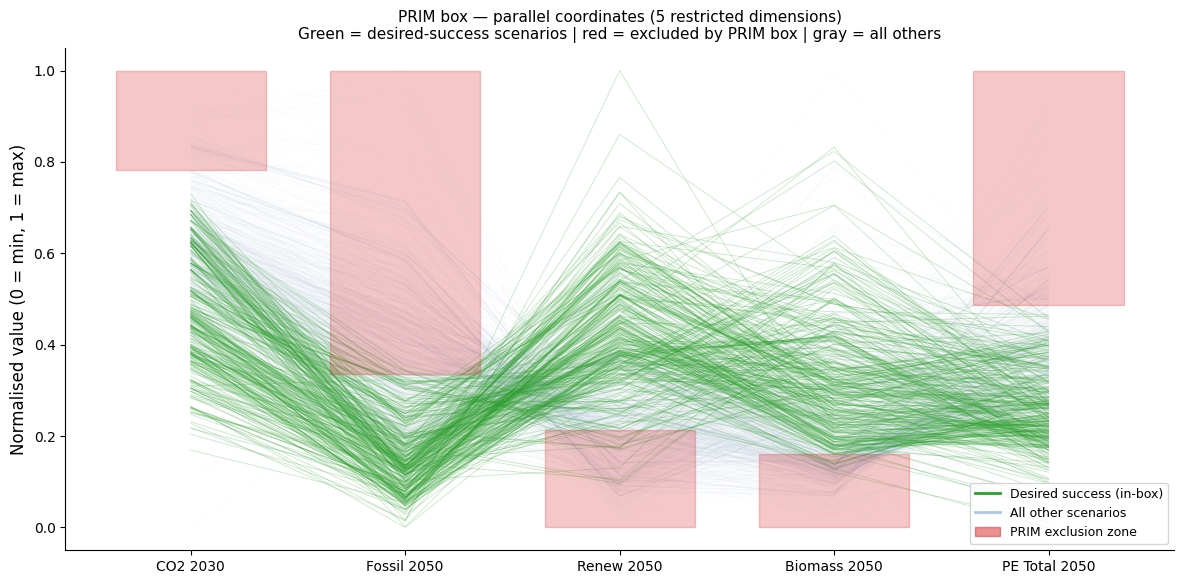

fig5 saved


In [11]:
pcp_df   = sub_prim[restricted + [OUTCOME]].dropna()
in_box   = pcp_df[OUTCOME].astype(bool).values

# Normalise each variable to [0,1]
normed = pcp_df[restricted].copy()
box_lo_n, box_hi_n = {}, {}
for col in restricted:
    lo, hi = pcp_df[col].min(), pcp_df[col].max()
    normed[col]   = (pcp_df[col] - lo) / (hi - lo) if hi > lo else 0.0
    box_lo_n[col] = (bl_sel.loc[0, col] - lo) / (hi - lo) if hi > lo else 0.0
    box_hi_n[col] = (bl_sel.loc[1, col] - lo) / (hi - lo) if hi > lo else 1.0

x_pos = np.arange(len(restricted))

fig, ax = plt.subplots(figsize=(12, 6))

# Out-of-box: thin gray
for _, row in normed[~in_box].iterrows():
    ax.plot(x_pos, row.values, color='#aec7e8', alpha=0.05, linewidth=0.4, zorder=1)

# In-box desired: green
for _, row in normed[in_box].iterrows():
    ax.plot(x_pos, row.values, color=C_DESIRED, alpha=0.25, linewidth=0.6, zorder=2)

# PRIM exclusion shading
for xi, col in enumerate(restricted):
    lo_n = box_lo_n[col]
    hi_n = box_hi_n[col]
    if lo_n > 0.02:
        ax.fill_betweenx([0, lo_n], xi-0.35, xi+0.35, color=C_PRIM, alpha=0.25, zorder=3)
    if hi_n < 0.98:
        ax.fill_betweenx([hi_n, 1.0], xi-0.35, xi+0.35, color=C_PRIM, alpha=0.25, zorder=3)

SHORT2 = {
    'Emissions|CO2|2030':                         'CO2 2030',
    'Primary Energy|Fossil|2030':                 'Fossil 2030',
    'Primary Energy|Fossil|2050':                 'Fossil 2050',
    'Primary Energy|Non-Biomass Renewables|2030': 'Renew 2030',
    'Primary Energy|Non-Biomass Renewables|2050': 'Renew 2050',
    'Primary Energy|Biomass|2050':                'Biomass 2050',
    'Primary Energy|2050':                        'PE Total 2050',
    'Final Energy|Electricity|2050':              'FE Elec 2050',
}

ax.set_xticks(x_pos)
ax.set_xticklabels([SHORT2.get(d, d) for d in restricted], fontsize=10)
ax.set_ylabel('Normalised value (0 = min, 1 = max)')
ax.set_ylim(-0.05, 1.05)
ax.set_title(
    f'PRIM box \u2014 parallel coordinates ({len(restricted)} restricted dimensions)\n'
    'Green = desired-success scenarios | red = excluded by PRIM box | gray = all others',
    fontsize=11)

leg = [
    Line2D([0],[0], color=C_DESIRED, lw=2, label='Desired success (in-box)'),
    Line2D([0],[0], color='#aec7e8', lw=2, label='All other scenarios'),
    mpatches.Patch(color=C_PRIM, alpha=0.5, label='PRIM exclusion zone'),
]
ax.legend(handles=leg, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fig5_prim_parallel_coordinates.png')
plt.show()
print('fig5 saved')

## Summary

In [12]:
from pathlib import Path
figs = sorted(Path('.').glob('fig*.png'))
print('Generated figures:')
for f in figs:
    print(f'  {f.name}')

print()
print('Slide mapping:')
print('  Slide 1 (Problem):       fig1_co2_fan_chart.png')
print('  Slide 2 (Method + tree): fig2b_cart_pruned_tree.png')
print('  Slide 3 (PRIM / space):  fig3_decision_space_scatter.png')
print('  Slide 4 (Mechanism):     fig4_two_roads_mechanism.png')
print('  Extra (PRIM box):        fig5_prim_parallel_coordinates.png')
print()
n_d = int(data['desired_success'].sum())
print(f'Key numbers: {n_d}/1599 desired success ({n_d/1599:.0%})')
print(f'CART #1 feature: {imps.index[0]} ({imps.iloc[0]:.3f})')
print(f'PRIM box: cov={sel_row["coverage"]:.0%}, density={sel_row["density"]:.0%}')
print(f'Primary CART split: Fossil 2050 = {primary_split:.0f} EJ/yr' if primary_split else 'No fossil split found')

Generated figures:
  fig1_co2_fan_chart.png
  fig2a_ccp_path.png
  fig2b_cart_pruned_tree.png
  fig3_decision_space_scatter.png
  fig4_two_roads_mechanism.png
  fig5_prim_parallel_coordinates.png

Slide mapping:
  Slide 1 (Problem):       fig1_co2_fan_chart.png
  Slide 2 (Method + tree): fig2b_cart_pruned_tree.png
  Slide 3 (PRIM / space):  fig3_decision_space_scatter.png
  Slide 4 (Mechanism):     fig4_two_roads_mechanism.png
  Extra (PRIM box):        fig5_prim_parallel_coordinates.png

Key numbers: 372/1599 desired success (23%)
CART #1 feature: Primary Energy|Fossil|2050 (0.825)
PRIM box: cov=91%, density=53%
Primary CART split: Fossil 2050 = 344 EJ/yr
